In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from google.colab import files
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

print("=== S.H.I.E.L.D FLOODSCOPE (2026) by Saad Ali ===")

=== S.H.I.E.L.D FLOODSCOPE (2026) by Saad Ali ===


Flood Risk Scoring and Diplay

In [ ]:
## FLOOD RISK SCORING ##


risk_colors = ['#d9f0d3','#a1d99b','#41ab5d','#005a32','#003300']
risk_cmap = ListedColormap(risk_colors)
risk_labels = {0: 'Very Low', 1: 'Low', 2: 'Moderate', 3: 'High', 4: 'Very High'}

def calculate_runoff_depth(cn, rainfall_depth=5.0):
    """Calculates physical runoff (Q) in inches using SCS-CN formula."""
    if cn <= 0: return 0
    S = (1000 / cn) - 10
    Ia = 0.2 * S
    return ((rainfall_depth - Ia)**2) / (rainfall_depth - Ia + S) if rainfall_depth > Ia else 0

def refined_flood_risk(row, df):
    """Scientific Risk Scoring: Physical Runoff + Topographic Accumulation."""
    q = calculate_runoff_depth(row['cn'])
    local_relief = row['elev'] - df['elev'].min()
    risk_score = 0

    if q > 3.5: risk_score += 4    # Physical Runoff Depth
    elif q > 2.5: risk_score += 3
    elif q > 1.5: risk_score += 2

    if local_relief < 3 and row['slope'] < 3: risk_score += 2 # Accumulation Zone
    if row['lulc'] == 6: risk_score += 2 # Built-up Area (Standardized ID)

    return min(4, max(0, risk_score // 2))

Upload CSV file with columns: id,elev,slope,lulc,soil,cn   create 37 rows:.  0=center, 1-36=6x6 grid)

Make a copy to proceed:
https://docs.google.com/spreadsheets/d/1IvLQsOliTf0UMMjvgj9D8yaozXSGRVr1quZ2IWoaBNQ/edit?usp=sharing

Please upload your CSV file (Values and Conditions)


Saving Values and Conditions - Sheet1(2).csv to Values and Conditions - Sheet1(2) (7).csv


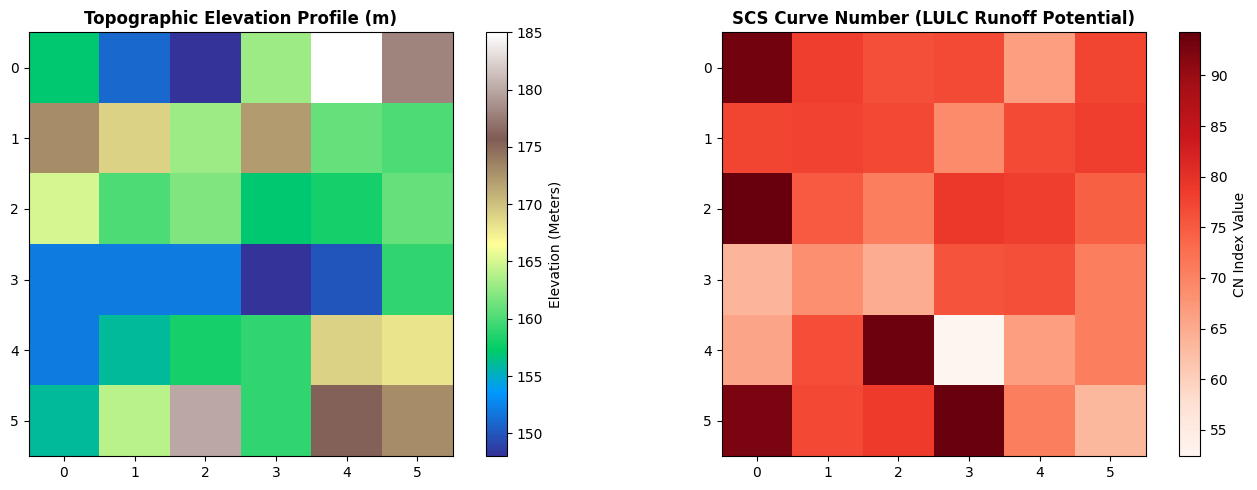

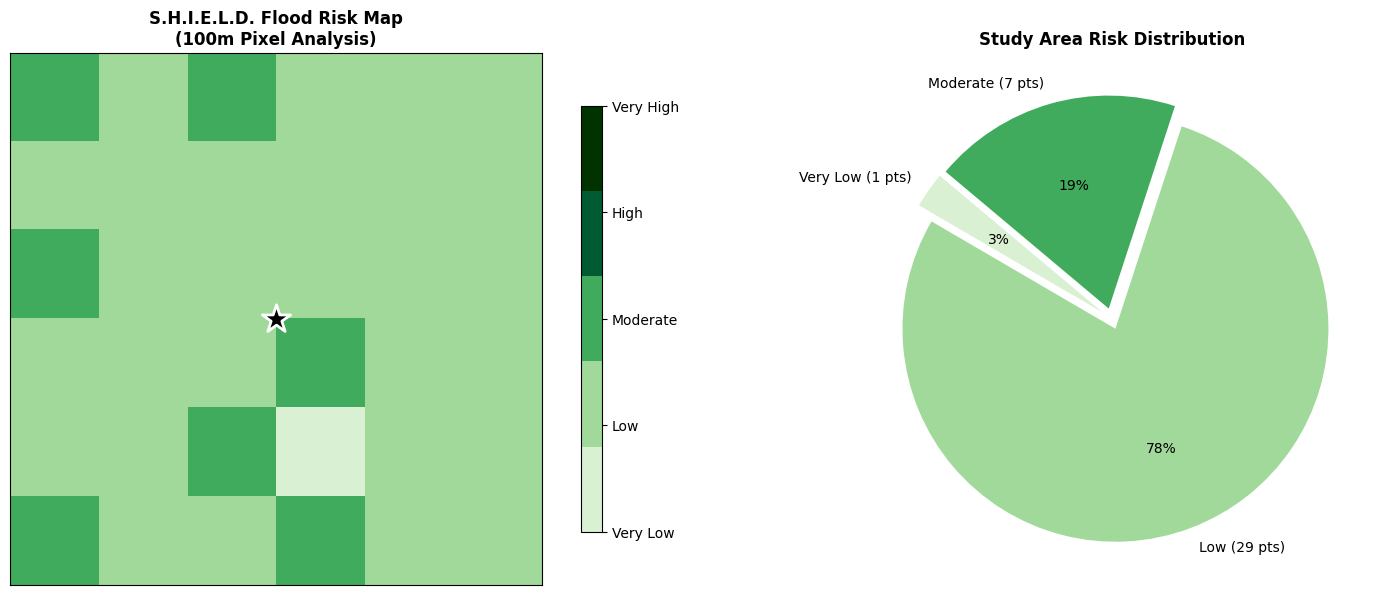

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:54:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


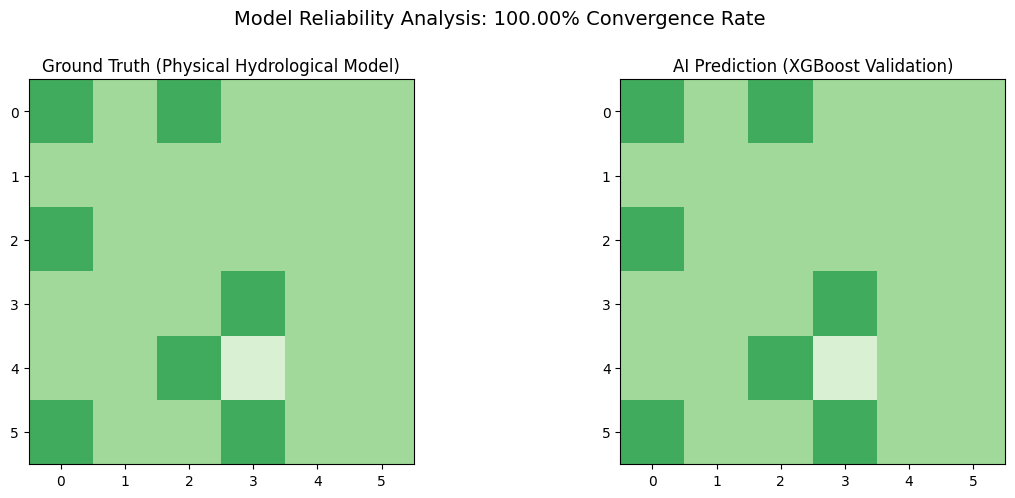


--- Summary of Predicted Risk by Coordinate ---
 id    level
  0      Low
  1 Moderate
  2      Low
  3 Moderate
  4      Low
  5      Low
  6      Low
  7      Low
  8      Low
  9      Low
 10      Low
 11      Low
 12      Low
 13 Moderate
 14      Low
 15      Low
 16      Low
 17      Low
 18      Low
 19      Low
 20      Low
 21      Low
 22 Moderate
 23      Low
 24      Low
 25      Low
 26      Low
 27 Moderate
 28 Very Low
 29      Low
 30      Low
 31 Moderate
 32      Low
 33      Low
 34 Moderate
 35      Low
 36      Low

[✔] Process Complete. Results saved to 'SHIELD_Final_Results.csv'


In [21]:
## DATA UPLOAD AND VISUALISATION ##


print("Please upload your CSV file (Values and Conditions)")
uploaded = files.upload()

if uploaded:
    file_name = list(uploaded.keys())[-1]
    df = pd.read_csv(file_name)
    df.columns = df.columns.str.lower().str.strip()

    # Apply Hydrological Logic #
    df['risk'] = df.apply(lambda r: refined_flood_risk(r, df), axis=1)


    grid_points = df[df['id'].between(1,36)]

    # VISUALISATION #

    fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5))

    # Elevation Map #
    elev_grid = grid_points['elev'].values.reshape(6,6)
    im0 = axes1[0].imshow(elev_grid, cmap='terrain')
    axes1[0].set_title('Topographic Elevation Profile (m)', fontweight='bold')
    plt.colorbar(im0, ax=axes1[0], label='Elevation (Meters)')

    # Curve Number Map #
    cn_grid = grid_points['cn'].values.reshape(6,6)
    im1 = axes1[1].imshow(cn_grid, cmap='Reds')
    axes1[1].set_title('SCS Curve Number (LULC Runoff Potential)', fontweight='bold')
    plt.colorbar(im1, ax=axes1[1], label='CN Index Value')
    plt.tight_layout()
    plt.show()

    fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))


    risk_grid = grid_points['risk'].values.reshape(6,6)
    im2 = axes2[0].imshow(risk_grid, cmap=risk_cmap, vmin=0, vmax=4)

    axes2[0].scatter(2.5, 2.5, c='black', s=450, marker='*', edgecolors='white', linewidths=2, label='Center Study Coordinate')
    axes2[0].set_title(f'S.H.I.E.L.D. Flood Risk Map\n(100m Pixel Analysis)', fontweight='bold')
    axes2[0].set_xticks([]); axes2[0].set_yticks([])

    cbar = fig2.colorbar(im2, ax=axes2[0], ticks=[0,1,2,3,4], shrink=0.8)
    cbar.ax.set_yticklabels(list(risk_labels.values()))

    # Risk Distribution #
    risk_counts = df['risk'].value_counts().sort_index()
    axes2[1].pie(risk_counts.values, labels=[f'{risk_labels[i]} ({v} pts)' for i,v in risk_counts.items()],
                  colors=risk_colors, autopct='%1.0f%%', startangle=140, explode=[0.05]*len(risk_counts))
    axes2[1].set_title('Study Area Risk Distribution', fontweight='bold')
    plt.tight_layout()
    plt.show()

  # MACHINE LEARNING VALIDATION #


    X = df[['elev', 'slope', 'lulc', 'soil', 'cn']]
    y = df['risk']

    xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
    xgb_model.fit(X, y)
    df['ml_pred'] = xgb_model.predict(X)

    fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))
    axes3[0].imshow(risk_grid, cmap=risk_cmap, vmin=0, vmax=4)
    axes3[0].set_title("Ground Truth (Physical Hydrological Model)")

    ml_grid = df.iloc[1:37]['ml_pred'].values.reshape(6,6)
    axes3[1].imshow(ml_grid, cmap=risk_cmap, vmin=0, vmax=4)
    axes3[1].set_title("AI Prediction (XGBoost Validation)")


    accuracy = (df['risk'] == df['ml_pred']).mean() * 100
    plt.suptitle(f"Model Reliability Analysis: {accuracy:.2f}% Convergence Rate", fontsize=14, y=1.02)
    plt.show()

    # DATA EXPORT #
    print("\n--- Summary of Predicted Risk by Coordinate ---")
    export_df = df[['id', 'risk']].copy()
    export_df['level'] = export_df['risk'].map(risk_labels)
    print(export_df[['id', 'level']].to_string(index=False))

    export_df.to_csv('SHIELD_Final_Results.csv', index=False)
    print("\n[✔] Process Complete. Results saved to 'SHIELD_Final_Results.csv'")
else:
    print("No data uploaded. Check CSV formatting.")